[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astheeggeggs/testing_colab/blob/main/rare_variant_SAIGE.ipynb)

# 🧬 SAIGE-Gene Rare Variant Association Analysis
Welcome to the practical session! Today, we will learn how to set up and run a gene-based rare variant association analysis using the **SAIGE-gene** framework.

We will start by running a fast, interactive pipeline on small toy datasets to master the workflow, and then explore pre-computed real-world results from the UK Biobank.

---

## 🛠️ Environment Initialization and SAIGE Installation
Before diving into genetics, we need to initialize our notebook's multi-language compiler extensions and build our local environment.

In [9]:
# Load the R magic extension so we can write native R inside this notebook
%load_ext rpy2.ipython

In [ ]:
# Clone the source code repository for SAIGE-gene
!git clone --depth 1 -b main https://github.com/saigegit/SAIGE /content/SAIGE

In [ ]:
# 1. Install the Pixi package manager
!curl -fsSL https://pixi.sh/install.sh | bash

# 2. Inject Pixi dynamically into our active shell environment paths
import os
os.environ['PATH'] = f"{os.environ['HOME']}/.pixi/bin:{os.environ['PATH']}"

# 3. Change directory to the source workspace and build project environments
%cd /content/SAIGE
!pixi install
!rm -rf ~/.cache
!pixi run Rscript -e 'install.packages("lintools", repos="https://cloud.r-project.org")'

In [ ]:
%cd /content/SAIGE

# 1. Fetch the exact source release version of PLINK2 required by SAIGE
!curl -L https://github.com/chrchang/plink-ng/archive/refs/tags/v2.0.0-a.6.16.tar.gz | tar -zx
!rm -rf plink-ng
!mv plink-ng-2.0.0-a.6.16 plink-ng

# 2. Compile the PLINK2 library native source archives using the Pixi environment compilers
!pixi run x86_64-conda-linux-gnu-cc -std=c++14 -fPIC -O3 -I.pixi/envs/default/include -L.pixi/envs/default/lib -o libplink2_includes.a plink-ng/2.0/include/*.cc -shared -lz -lzstd -lpthread -lm -ldeflate
!mv libplink2_includes.a .pixi/envs/default/lib

In [ ]:
import os

# 1. Sever connection to pre-existing system configurations to avoid compiler conflicts
for var in ['R_HOME', 'R_LIBS', 'R_LIBS_USER', 'R_LIBS_SITE']:
    if var in os.environ:
        del os.environ[var]

# 2. Bind the user library path directly to the isolated sandboxed environment
os.environ['R_LIBS_USER'] = '/content/SAIGE/.pixi/envs/default/lib/R/library'

# 3. Build and globally install the SAIGE engine module
%cd /content/SAIGE
!pixi run R CMD INSTALL .

> ⚠️ **CRITICAL CHECKPOINT:** The installation code cell directly above must conclude with a message reading `* DONE (SAIGE)`. If it doesn't, shout - you won't be the only one, and we'll help you diagnose what went wrong. If it does....read on!

---

# 🟢 Step 0: Constructing a Sparse Genetic Relationship Matrix (GRM)

This step calculates the genetic background relationships across samples. It is required for running region- and gene-based score tests within SAIGE-Gene.

> 💡 **Key Concept:** A sparse GRM only needs to be computed **once** for a target cohort (e.g., a biobank population) and can be saved and reused across different phenotypes, provided the overall sample list doesn't change.

In [ ]:
%cd /content/SAIGE
!pixi run Rscript extdata/createSparseGRM.R --help

### Reviewing the Command Options
Take a while to look over these construction flags before running the next cell:

* `--plinkFile`: Points to the genotype files prefix (`.bed`, `.bim`, `.fam`).
* `--nThreads`: Determines processing cores (set to 4 here).
* `--relatednessCutoff`: Genetic threshold below which relationships are set to 0, ensuring the matrix stays computationally light and "sparse."

**Expected Input Files Found Under `./extdata/input/`:**
* `nfam_100_nindep_0_step1_includeMoreRareVariants_poly.bed`
* `nfam_100_nindep_0_step1_includeMoreRareVariants_poly.bim`
* `nfam_100_nindep_0_step1_includeMoreRareVariants_poly.fam`

**Generated Outputs Stored Under `./extdata/output/`:**
* `sparseGRM_relatednessCutoff_0.125_1000_randomMarkersUsed.sparseGRM.mtx` (The core matrix file; can be inspected in R using `Matrix::readMM()`).
* `sparseGRM_relatednessCutoff_0.125_1000_randomMarkersUsed.sparseGRM.mtx.sampleIDs.txt` (The ordered string list of sample IDs matching rows/columns).

These filenames are a bit of a mouthful, but provide super useful information about how they were constructed.

In [ ]:
!pixi run Rscript extdata/createSparseGRM.R \
  --plinkFile=extdata/input/nfam_100_nindep_0_step1_includeMoreRareVariants_poly \
  --nThreads=4 \
  --outputPrefix=extdata/output/sparseGRM \
  --numRandomMarkerforSparseKin=1000 \
  --relatednessCutoff=0.125

The screen output ends with the following text if the job above has been run successfully:

```
[999,] .         .         .         .         ......
[1000,] .         .         .         .         ......

 .....suppressing 968 columns in show(); maybe adjust options(max.print=, width=)
 ..............................
```

If you see this, **move to the next step!**

---

# 🔵 Step 1: Fitting the Null Logistic/Linear Mixed Model

Next, we fit a null generalised linear mixed model (GLMM) accounting for baseline covariates (e.g., age, biological sex, and genetic principal components [PCs]), and population structure via the sparse GRM. This defines our baseline variation under the **null hypothesis of no genetic association**.

Depending on the trait type of the phenotype, $y$ say, SAIGE applies either a linear model (for continuous $y$) or a logistic model (for binary $y$). In the case of binary $y$, we might have:

$$\text{logit}(\pi) = X\beta + b$$

* $\pi$: The probability that an individual displays the binary outcome (that is, $y = 1$).
* $X\beta$: The fixed effects covariate matrix (e.g., Age, Sex, PCs).
* $b$: The random effect vector modeling background relatedness, distributed as $b \sim N(0, \tau \Sigma)$ where $\Sigma$ is your constructed GRM (i.e. it's a correlated noise term).

Let's run a script to perform step 1 of SAIGE, and inspect what's going on under the hood.

In [ ]:
!pixi run Rscript extdata/step1_fitNULLGLMM.R \
  --sparseGRMFile=extdata/output/sparseGRM_relatednessCutoff_0.125_1000_randomMarkersUsed.sparseGRM.mtx \
  --sparseGRMSampleIDFile=extdata/output/sparseGRM_relatednessCutoff_0.125_1000_randomMarkersUsed.sparseGRM.mtx.sampleIDs.txt \
  --useSparseGRMtoFitNULL=TRUE \
  --plinkFile=extdata/input/nfam_100_nindep_0_step1_includeMoreRareVariants_poly_22chr.forCate_vr \
  --phenoFile=extdata/input/pheno_1000samples.txt_withdosages_withBothTraitTypes.txt \
  --isCateVarianceRatio=TRUE \
  --phenoCol=y_binary \
  --covarColList=x1,x2 \
  --qCovarColList=x2 \
  --sampleIDColinphenoFile=IID \
  --traitType=binary \
  --nThreads=1 \
  --outputPrefix=extdata/output/example_binary_sparseGRM \
  --IsOverwriteVarianceRatioFile=TRUE &> step1_fitNULLGLMM.log

As a reminder, you can see all of the options for SAIGE step 1 in gory detail
by running...

In [ ]:
!pixi run Rscript step1_fitNULLGLMM.R --help

Take a look in `step1_fitNULLGLMM.log`:

In [ ]:
!cat step1_fitNULLGLMM.log

Does the log file end with...
```varRatio_null_noXadj 0.9413749
         V1          V2 V3
1 0.9485805        null  1
2 0.9451629 null_noXadj  1
3 0.9441699        null  2
4 0.9413749 null_noXadj  2
closed the plinkFile!
```

If you see this, **move to the next step**!

---

# 🟣 Step 2: Executing Gene-Based & Set-Based Association Tests

With our null model established, we can read a target marker file containing genotypes or dosages (supporting `VCF`, `BCF`, `BGEN`, or `SAV` - we'll use `BGEN` today) alongside a **group specification file** to run aggregated gene-level calculations like SKAT, Burden, and SKAT-O tests. Here's all the input files we need for step 2:

## Input files
####Dosage/genotype file containing dosages or genotypes of markers to test
`extdata/input/genotype_100markers.bgen`
`extdata/input/genotype_100markers.bgen.bgi`

The `.bgi` file is an index - it allows huge speedups if we want to zip to different parts of the bgen or slice and dice the data.

####Sample file

This file contains one column for sample IDs corresponding to the sample order in the dosage file. No header is included. The file is ONLY for `BGEN` input.

`extdata/input/samplelist.txt`

####Model file from step 1
`extdata/output/example_binary_sparseGRM.rda`

####Variance ratio file from step 1

`extdata/output/example_binary_sparseGRM.varianceRatio.txt`

#### Group File (specific to SAIGE-gene)

`extdata/input/group_new_chrposa1a2.txt`

### Understanding the Group File Format
A group mapping file structures variants into specific genomic sets (e.g., matching a gene identifier). It contains at least two lines for each gene/set. The first two lines are required:
1.  **`var` line:** The gene name followed by structural variant identifiers.
2.  **`anno` line:** The functional annotations matching each variant sequence item.
Optionally, you can include a third line representing the 'weights' for each marker:
3.  **`weight` line** *(optional)***:** Explicit weights per marker. If missing, SAIGE dynamically weights variants via a Beta distribution profile based on Minor Allele Frequency: $\text{Beta}(\text{MAF}, 1, 25)$.

Take a look in the group file that we're going to use for this practical:

In [ ]:
%%R
groupfile <- readLines("extdata/input/group_new_chrposa1a2.txt")
print(groupfile)

Does the output make sense?

Can you go into R (or python if you're so inclined) and plot what this default $\text{Beta}(\text{MAF}, 1, 25)$ distribution looks like?

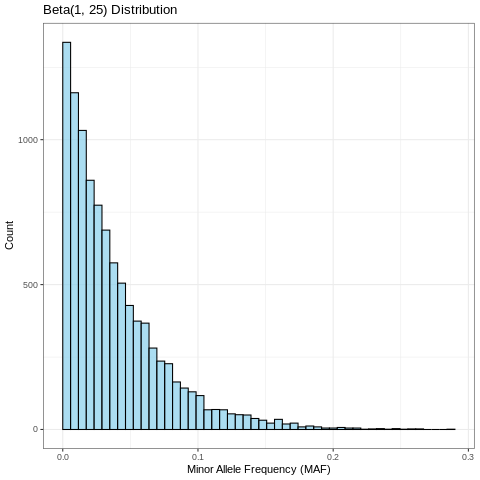

In [10]:
%%R
library(ggplot2)

set.seed(42)
df <- data.frame(MAF = rbeta(10000, 1, 25))

ggplot(df, aes(x = MAF)) +
  geom_histogram(bins = 50, fill = "skyblue", color = "black", alpha = 0.7,
                 boundary = 0) +
  theme_bw() +
  labs(title = "Beta(1, 25) Distribution",
       x = "Minor Allele Frequency (MAF)",
       y = "Count")

Does this make sense? Why?

In [ ]:
# View parameter descriptions for the Step 2 association runner
!pixi run Rscript extdata/step2_SPAtests.R --help

In [ ]:
!pixi run Rscript extdata/step2_SPAtests.R \
    --bgenFile=extdata/input/genotype_100markers.bgen \
    --bgenFileIndex=extdata/input/genotype_100markers.bgen.bgi \
    --SAIGEOutputFile=extdata/output/genotype_100markers_bgen_groupTest_out.txt \
    --chrom=1 \
    --AlleleOrder=ref-first \
    --minMAF=0 \
    --minMAC=0.5 \
    --sampleFile=extdata/input/samplelist.txt \
    --GMMATmodelFile=extdata/output/example_binary_sparseGRM.rda \
    --varianceRatioFile=extdata/output/example_binary_sparseGRM.varianceRatio.txt \
    --groupFile=extdata/input/group_new_chrposa1a2.txt \
    --annotation_in_groupTest="lof,missense:lof,missense:lof:synonymous" \
    --maxMAF_in_groupTest=0.0001,0.001,0.01 \
    --is_output_markerList_in_groupTest=TRUE \
    --LOCO=FALSE \
    --is_fastTest=TRUE

The screen output ends with the following text if the job above has been run successfully:
```
[1] "Analysis done! The set-based tests results have been saved to 'extdata/output/genotype_100markers_bgen_groupTest_out.txt'. The marker lists have been saved to 'extdata/output/genotype_100markers_bgen_groupTest_out.txt.markerList.txt'. The single-variant association tests results have been saved to 'extdata/output/genotype_100markers_bgen_groupTest_out.txt.singleAssoc.txt'."
Warning message:
In SAIGE.getRegionList_new(marker_group_line, nline_per_gene, annolist,  :
  No markers are found for at least one annotation, so region GENE3 is skipped
```
**Congratulations, you've run SAIGE-gene from start to finish!**

Try running the help flag for step 2 and have a read about what each of the flags are doing.

In [ ]:
!pixi run Rscript extdata/step2_SPAtests.R --help


Take a look in the output file for the gene-based tests.

What are each of the entries showing?

In [ ]:
%%R
library(data.table)

dt <- fread("extdata/output/genotype_100markers_bgen_groupTest_out.txt")
print(dt)

---

# 📈 Part 2: Working with Real-World Biobank Datasets

When dealing with massive human population biobanks, processing complete genomes requires substantial computing clusters. To save time during our live workshop, we have provided an example dataset containing the finished gene-level analysis results of Atrial Fibrillation (AFib) from a EUR-like genetic ancestry subgroup within the UK Biobank ($N = 28,671$ cases; $373,704$ controls).

First, we need to copy across this summary statistic data into our workspace.

In [7]:
!python -m pip -q install gdown
!gdown --fuzzy https://drive.google.com/file/d/1rwLaX-Fuq64TOEjlW3aGbt7R2EB4USH1/view?usp=drive_link -O /content/

Downloading...
From: https://drive.google.com/uc?id=1rwLaX-Fuq64TOEjlW3aGbt7R2EB4USH1
To: /content/pilot-traits_uk-biobank_gene_uk-biobank.palmer.pilot.AFib.JULY23Freeze.ALL.EUR.28671.373704.SAIGE.gene.20240110.txt.gz
100% 15.1M/15.1M [00:00<00:00, 241MB/s]


### ❓ Question 2.1
What functional classes of genetic variant tests have been evaluated here? Inspect the data file structure and columns.

<details>
<summary>💡 Click here to reveal the answer!</summary>

Four primary distinct functional annotation groupings were evaluated:
1. **`pLoF`** (Predicted Loss-of-Function)
2. **`damaging_missense_or_protein_altering`**
3. **`other_missense_or_protein_altering`**
4. **`synonymous`**

Combinations were also tested together as unified groups inside the analysis:
`pLoF;damaging_missense_or_protein_altering` and an all-inclusive nested configuration. These categories are stored directly under the **`Group`** column.
</details>

### ❓ Question 2.3
What Minor Allele Frequency (MAF) thresholds were configured as cutoffs across these variant sets?

<details>
<summary>💡 Click here to reveal the answer!</summary>

The evaluation tracks filtering cutoff limits at **0.01 (1%)**, **0.001 (0.1%)**, and **0.0001 (0.01%)** parameters.
You can confirm this by parsing data records listed within the **`max_MAF`** variable column.
</details>

### 📊 Question 2.4: Generating a Quantile-Quantile (QQ) Plot
How do the results in synonymous variation look? Can you create a QQ plot?

Let's write a script to build a high-resolution QQ plot of our Synonymous variant groupings using `ggplot2` to inspect the distribution of observed p-values against expectation.

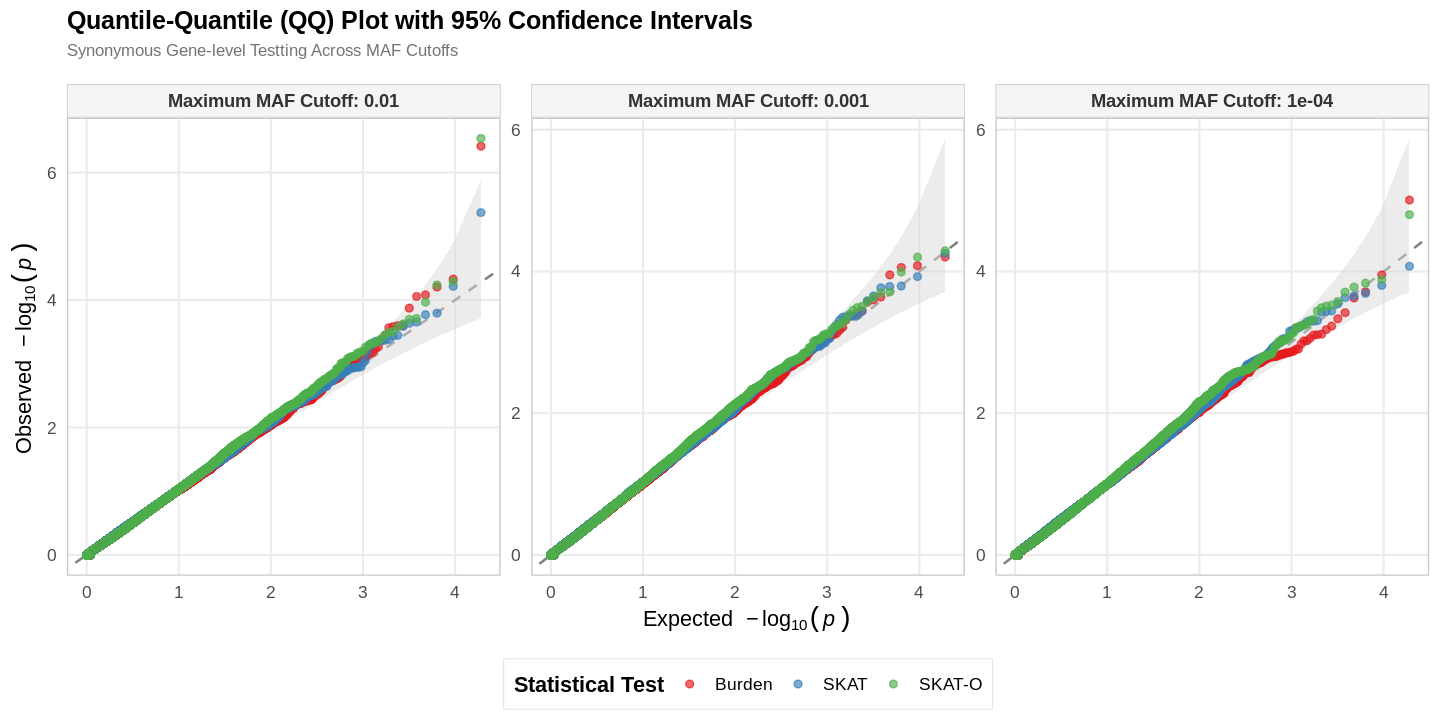

In [40]:
%%R -w 12 -h 6 --units in -r 120
library(data.table)
library(dplyr)
library(tidyr)
library(ggplot2)

# 1. Load Data Safely
setwd("/content")
dt <- fread(cmd = "zcat pilot-traits_uk-biobank_gene_uk-biobank.palmer.pilot.AFib.JULY23Freeze.ALL.EUR.28671.373704.SAIGE.gene.20240110.txt.gz")

# 2. Advanced Data Pipeline with Ordered Factors and Confidence Intervals
plot_data <- dt %>%
  filter(Group != "Cauchy") %>%
  pivot_longer(
    cols = c(Pvalue, Pvalue_Burden, Pvalue_SKAT),
    names_to = "class",
    values_to = "Pvalue"
  ) %>%
  mutate(
    class = case_match(
      class,
      "Pvalue"        ~ "SKAT-O",
      "Pvalue_Burden" ~ "Burden",
      "Pvalue_SKAT"   ~ "SKAT"
    ),
    Group = case_match(
      Group,
      "damaging_missense_or_protein_altering" ~ "Damaging missense",
      "other_missense_or_protein_altering"    ~ "Other missense",
      "pLoF"                                  ~ "pLoF",
      "pLoF;damaging_missense_or_protein_altering" ~ "pLoF, damaging missense",
      "pLoF;damaging_missense_or_protein_altering;other_missense_or_protein_altering;synonymous" ~ "pLoF, damaging missense, other missense, synonymous",
      "synonymous"                            ~ "Synonymous"
    ),
    # Create the clean string label
    max_MAF_label = paste0("Maximum MAF Cutoff: ", max_MAF)
  ) %>%
  filter(Group == "Synonymous") %>%
  # --- FIX 1: Sort by numeric MAF descending to lock in your custom facet order ---
  arrange(desc(max_MAF)) %>%
  mutate(max_MAF_label = factor(max_MAF_label, levels = unique(max_MAF_label))) %>%
  # Process mathematical ranks and null distributions
  group_by(class, Group, max_MAF) %>%
  arrange(Pvalue, .by_group = TRUE) %>%
  mutate(
    rank = row_number(),
    n_total = n(),
    Pvalue_exp = rank / (n_total + 1),
    lower_ci = qbeta(0.025, rank, n_total - rank + 1),
    upper_ci = qbeta(0.975, rank, n_total - rank + 1)
  ) %>%
  ungroup()

p <- ggplot(plot_data, aes(x = -log10(Pvalue_exp), y = -log10(Pvalue))) +

  # Identity Line
  geom_abline(intercept = 0, slope = 1, color = "grey50", linetype = "dashed", linewidth = 0.7) +
  geom_ribbon(
    data = filter(plot_data, class == "SKAT-O"),
    aes(x = -log10(Pvalue_exp), ymin = -log10(upper_ci), ymax = -log10(lower_ci)),
    fill = "grey85",
    alpha = 0.5,
    inherit.aes = FALSE
  ) +

  geom_point(aes(color = class), size = 1.8, alpha = 0.65) +

  # Multi-panel grid layout
  facet_wrap(~max_MAF_label, scales = 'free') +
  scale_color_brewer(palette = "Set1") +

  # Fine-Tuning Presentation Theme
  theme_minimal(base_size = 13) +
  theme(
    panel.border       = element_rect(color = "grey80", fill = NA, linewidth = 0.8),
    panel.grid.minor   = element_blank(),
    strip.background   = element_rect(fill = "grey96", color = "grey80", linewidth = 0.5),
    strip.text         = element_text(face = "bold", color = "grey20", size = 11),
    legend.position    = "bottom",
    legend.title       = element_text(face = "bold"),
    legend.background  = element_rect(fill = "white", color = "grey90", linewidth = 0.3),
    plot.title         = element_text(face = "bold", size = 15, margin = margin(b = 6)),
    plot.subtitle      = element_text(color = "grey45", size = 10, margin = margin(b = 15))
  ) +
  labs(
    title    = "Quantile-Quantile (QQ) Plot with 95% Confidence Intervals",
    subtitle = "Synonymous Gene-level Testting Across MAF Cutoffs",
    x        = expression(Expected~-log[10](italic(p))),
    y        = expression(Observed~-log[10](italic(p))),
    color    = "Statistical Test"
  )
print(p)

Discuss these plots in your group. What do you notice?

You should have noticed that there's lift off from $y=x$ for synonymous variation, suggesting that there could well be common variant associations nearby that you're tagging. It might be a good idea to look and see if there are common variant associations close to those lead gene-phenotype associations.

---
🏁 **Congratulations!** You have completed the practical execution pipeline guide for running SAIGE-Gene rare variant mapping analyses.